# Multi-channel linearized gap equation

This notebook rewrites the structure of `chi2_old.m` in Python and keeps the main building blocks as close as possible to the MATLAB code:

- the normal-state Hamiltonians `H0` and `H0p`
- the eight pairing vertices `Gam[:,:,1:8]`
- the fermionic bubbles `bubble` and `bubblep`
- the block-structured pairing kernel `Mchi`
- the eigenvalue problem `eigs(-pref * Mchi, ...)`

Compared with the earlier single-channel notebook, this version restores the multi-channel structure of the linearized gap equation. The markdown is also expanded so it is easier to compare each Python block with the original MATLAB implementation.


## Practical note on defaults

The original MATLAB script uses `Nk_base = 31`, which means the sampled grid has `Nk = Nk_base + 1 = 32` points along each momentum direction because both `-pi` and `pi` are included. That choice makes the full kernel very large:

$$
\mathrm{dim}(M_\chi) = 8 N_k^2.
$$

For interactive notebook use, the default below is lighter than the MATLAB setting. To get closer to the original script, set `Nk_base = 31` and keep in mind that both runtime and memory usage will increase sharply.


In [7]:
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
from numpy.linalg import inv
from scipy.interpolate import RectBivariateSpline
from scipy.sparse.linalg import eigs


@dataclass
class ModelParams:
    # Grid: MATLAB uses Nk_base = 31 and then sets Nk = Nk_base + 1.
    Nk_base: int = 31

    # Band and interaction parameters.
    # Paper convention in the shown section: t=1, t_a'=-0.3, t_b'=0.2,
    # no SOC, and r/J=1.5. Here m plays the role of r, so m/J=1.5.
    m: float = 1.0
    J: float = 0.93
    mu: float = 2.5
    tp: float = 0.2
    tpp: float = -0.3
    lam: float = 0.00
    t: float = 1.0
    T: float =  0.008108

    # Matsubara cutoff: MATLAB sums n = -Nw-1, ..., Nw.
    Nw: int = 30

    # Small momentum regularizer used in chi2_old.m.
    delta: float = 1e-15

    # Number of leading eigenvalues to request.
    num_eigs: int = 10

    # Classification tolerance for the leading mode.
    classify_tol: float = 1e-9

    # Save arrays to disk.
    save_outputs: bool = True


params = ModelParams()
params

ModelParams(Nk_base=31, m=1.0, J=0.93, mu=2.5, tp=0.2, tpp=-0.3, lam=0.0, t=1.0, T=0.008108, Nw=30, delta=1e-15, num_eigs=10, classify_tol=1e-09, save_outputs=True)

## Pauli matrices, momentum grid, and model ingredients

The original MATLAB code works with a four-component normal-state Hamiltonian and builds matrices using Kronecker products of Pauli matrices. We keep the same notation here. The Pauli matrices are

$$
\begin{aligned}
\tau_0 &= \begin{pmatrix}1 & 0 \\ 0 & 1\end{pmatrix}, &
\tau_1 &= \begin{pmatrix}0 & 1 \\ 1 & 0\end{pmatrix}, \\
\tau_2 &= \begin{pmatrix}0 & -i \\ i & 0\end{pmatrix}, &
\tau_3 &= \begin{pmatrix}1 & 0 \\ 0 & -1\end{pmatrix}.
\end{aligned}
$$

The normal-state Hamiltonian used in the kernel is

$$
\begin{aligned}
H_0(k_x,k_y) ={}& \left[-(t' + t'')\left(\cos k_x + \cos k_y\right)-\mu\right] \, \tau_0\otimes\tau_0 \\
&{} -4t\cos\frac{k_x}{2}\cos\frac{k_y}{2} \, \tau_1\otimes\tau_0 \\
&{} + \lambda\sin\frac{k_x}{2}\sin\frac{k_y}{2} \, \tau_2\otimes\tau_3 \\
&{} + (t' - t'')\left(\cos k_x - \cos k_y\right) \, \tau_3\otimes\tau_0 .
\end{aligned}
$$

The companion matrix `H0p` used for `bubblep` follows the MATLAB script:

$$
\begin{aligned}
H'_0(k_x,k_y) ={}& \left[-(t' + t'')\left(\cos k_x + \cos k_y\right)-\mu\right] \, \tau_0\otimes\tau_0 \\
&{} +4t\cos\frac{k_x}{2}\cos\frac{k_y}{2} \, \tau_1\otimes\tau_0 \\
&{} - \lambda\sin\frac{k_x}{2}\sin\frac{k_y}{2} \, \tau_2\otimes\tau_3 \\
&{} + (t' - t'')\left(\cos k_x - \cos k_y\right) \, \tau_3\otimes\tau_0 .
\end{aligned}
$$

So compared with `H0`, only the $\tau_1\otimes\tau_0$ hopping term and the spin-orbit-like $\tau_2\otimes\tau_3$ term change sign.

The code follows the paper ordering of the eight attractive pairing vertices in Eq. (S5):

$$
\begin{aligned}
\Gamma_1 &= \tau_0\otimes\sigma_0, &
\Gamma_2 &= \tau_3\otimes\sigma_3, \\
\Gamma_3 &= \tau_3\otimes\sigma_0, &
\Gamma_4 &= \tau_0\otimes\sigma_3, \\
\Gamma_5 &= \tau_1\otimes\sigma_2, &
\Gamma_6 &= \tau_2\otimes\sigma_1, \\
\Gamma_7 &= \tau_1\otimes\sigma_1, &
\Gamma_8 &= \tau_2\otimes\sigma_2.
\end{aligned}
$$

The linearized gap vector is therefore represented numerically as

$$
\Delta(k_x,k_y)=\sum_{a=1}^{8}\Delta_a(k_x,k_y)\Gamma_a,
$$

where the unknown functions `Delta_a(kx, ky)` are solved on the momentum grid rather than assumed from a harmonic expansion.

The momentum grid is also matched to the MATLAB convention:

$$
k_x, k_y \in \left\{-\pi, -\pi + \frac{2\pi}{N_k^{\mathrm{base}}}, \ldots, \pi\right\}.
$$

Because the endpoint is included, the actual number of grid points per direction is

$$
N_k = N_k^{\mathrm{base}} + 1.
$$

This is slightly different from the more common `endpoint=False` grid that avoids duplicating `-pi` and `pi`, but here we intentionally follow the MATLAB script.


In [8]:
tau0 = np.array([[1, 0], [0, 1]], dtype=complex)
tau1 = np.array([[0, 1], [1, 0]], dtype=complex)
tau2 = np.array([[0, -1j], [1j, 0]], dtype=complex)
tau3 = np.array([[1, 0], [0, -1]], dtype=complex)


def make_grid(p: ModelParams):
    x = -np.pi + 2.0 * np.pi * np.arange(p.Nk_base + 1) / p.Nk_base
    y = -np.pi + 2.0 * np.pi * np.arange(p.Nk_base + 1) / p.Nk_base
    qx, qy = np.meshgrid(x, y, indexing="xy")
    Nk = p.Nk_base + 1
    vqx = qx.reshape(Nk * Nk)
    vqy = qy.reshape(Nk * Nk)
    dxy = (x[1] - x[0]) * (y[1] - y[0])
    pref = dxy * p.T / (2.0 * np.pi) ** 2
    return x, y, qx, qy, vqx, vqy, Nk, dxy, pref


def H0(kx, ky, p: ModelParams):
    return (
        (-(p.tp + p.tpp) * (np.cos(kx) + np.cos(ky)) - p.mu) * np.kron(tau0, tau0)
        + (-4.0 * p.t * np.cos(kx / 2.0) * np.cos(ky / 2.0)) * np.kron(tau1, tau0)
        + (p.lam * np.sin(kx / 2.0) * np.sin(ky / 2.0)) * np.kron(tau2, tau3)
        + ((p.tp - p.tpp) * (np.cos(kx) - np.cos(ky))) * np.kron(tau3, tau0)
    )


def H0p(kx, ky, p: ModelParams):
    return (
        (-(p.tp + p.tpp) * (np.cos(kx) + np.cos(ky)) - p.mu) * np.kron(tau0, tau0)
        + (4.0 * p.t * np.cos(kx / 2.0) * np.cos(ky / 2.0)) * np.kron(tau1, tau0)
        + (-p.lam * np.sin(kx / 2.0) * np.sin(ky / 2.0)) * np.kron(tau2, tau3)
        + ((p.tp - p.tpp) * (np.cos(kx) - np.cos(ky))) * np.kron(tau3, tau0)
    )


def build_gamma_matrices():
    # Paper Eq. (S5) ordering for the eight attractive channels.
    Gam = np.zeros((8, 4, 4), dtype=complex)
    Gam[0] = np.kron(tau0, tau0)  # Gamma1
    Gam[1] = np.kron(tau3, tau3)  # Gamma2
    Gam[2] = np.kron(tau3, tau0)  # Gamma3
    Gam[3] = np.kron(tau0, tau3)  # Gamma4
    Gam[4] = np.kron(tau1, tau2)  # Gamma5
    Gam[5] = np.kron(tau2, tau1)  # Gamma6
    Gam[6] = np.kron(tau1, tau1)  # Gamma7
    Gam[7] = np.kron(tau2, tau2)  # Gamma8
    return Gam


x, y, qx, qy, vqx, vqy, Nk, dxy, pref = make_grid(params)
Ntot = Nk * Nk
Gam = build_gamma_matrices()
eye4 = np.eye(4, dtype=complex)

print(f"Nk_base = {params.Nk_base}, Nk = {Nk}, Ntot = {Ntot}")
print(f"prefactor = {pref:.6e}")


Nk_base = 31, Nk = 32, Ntot = 1024
prefactor = 8.437045e-06


## Bubble functions `bubble` and `bubblep`

The MATLAB script computes two fermionic bubble tensors:

$$
\mathrm{bubble}(\mathbf{k}, a, b)
= \sum_n \mathrm{Tr}\left[G_p(i\omega_n, \mathbf{k}) \Gamma_a G_h(i\omega_n, \mathbf{k}) \Gamma_b\right],
$$

and an analogous `bubblep` constructed from `H0p`.

With the paper channel ordering, Eq. (S39) leaves only three diagonal channel blocks:

- channels `1:4`, the p-wave sector
- channels `5:6`, the s'/d' sector
- channels `7:8`, the p' sector

All other channel couplings are left at zero. The Python loop below follows that same structure.


In [9]:
def build_hamiltonian_tables(vqx, vqy, p: ModelParams):
    H_table = np.zeros((len(vqx), 4, 4), dtype=complex)
    Hp_table = np.zeros((len(vqx), 4, 4), dtype=complex)
    for ik, (kx, ky) in enumerate(zip(vqx, vqy)):
        H_table[ik] = H0(kx, ky, p)
        Hp_table[ik] = H0p(kx, ky, p)
    return H_table, Hp_table


def block_ranges():
    # Paper Eq. (S39): Gamma1-4, Gamma5-6, and Gamma7-8 do not mix.
    return [range(0, 4), range(4, 6), range(6, 8)]


def compute_bubbles(vqx, vqy, Gam, p: ModelParams, verbose=True):
    H_table, Hp_table = build_hamiltonian_tables(vqx, vqy, p)
    bubble = np.zeros((len(vqx), 8, 8), dtype=complex)
    bubblep = np.zeros((len(vqx), 8, 8), dtype=complex)

    for gid_block in block_ranges():
        if verbose:
            print(f"Computing block {gid_block.start + 1}:{gid_block.stop} ...")

        for gid1 in gid_block:
            for gid2 in gid_block:
                G1 = Gam[gid1]
                G2 = Gam[gid2]

                for ik in range(len(vqx)):
                    Hk = H_table[ik]
                    Hkp = Hp_table[ik]

                    accum = 0.0 + 0.0j
                    accump = 0.0 + 0.0j

                    for n in range(-p.Nw - 1, p.Nw + 1):
                        freq = (2 * n + 1) * np.pi * p.T
                        iwn = 1j * freq * eye4

                        Gp = inv(iwn - Hk)
                        Gh = inv(iwn + Hk.T)
                        accum += np.trace(Gp @ G1 @ Gh @ G2)

                        Gpp = inv(iwn - Hkp)
                        Ghp = inv(iwn + Hkp.T)
                        accump += np.trace(Gpp @ G1 @ Ghp @ G2)

                    bubble[ik, gid1, gid2] = accum
                    bubblep[ik, gid1, gid2] = accump

    return bubble, bubblep


## Pairing kernel `Mchi`

The large kernel matrix has dimension `8 * Ntot` by `8 * Ntot`, where `Ntot = Nk^2`. Its row index is a pair `(a, i)` and its column index is a pair `(b, j)`, with channel labels `a,b = 1, ..., 8` and momentum-grid points

$$
\mathbf{p}_i=(p_{x,i},p_{y,i}),\qquad
\mathbf{k}_j=(k_{x,j},k_{y,j}).
$$

The interaction pieces in the code are

$$
\chi_{s}(\mathbf{q})=
\frac{1}{4\left[\delta(q_x^2+q_y^2)+m+sJ\cos(q_x/2)\cos(q_y/2)\right]},
\qquad s=\pm 1.
$$

Thus `minus_pm`, `minus_pp`, `plus_pm`, and `plus_pp` correspond to

$$
\begin{aligned}
\chi_-(\mathbf{p}_i-\mathbf{k}_j),\quad
\chi_-(\mathbf{p}_i+\mathbf{k}_j),\quad
\chi_+(\mathbf{p}_i-\mathbf{k}_j),\quad
\chi_+(\mathbf{p}_i+\mathbf{k}_j),
\end{aligned}
$$

where `minus` means the denominator contains `m - J cos(qx/2) cos(qy/2)`, and `plus` means it contains `m + J cos(qx/2) cos(qy/2)`.

Let

$$
B_{ab}(\mathbf{k}_j)=\mathrm{bubble}(\mathbf{k}_j,a,b),\qquad
B'_{ab}(\mathbf{k}_j)=\mathrm{bubblep}(\mathbf{k}_j,a,b).
$$

Then the nonzero matrix elements of `Mchi` are the following three block formulas.

For the paper `Gamma1:Gamma4` p-wave sector, meaning `a,b in {1,2,3,4}`:

$$
\begin{aligned}
(M_\chi)_{ai,bj}={}&
B_{ab}(\mathbf{k}_j)\left[\chi_-(\mathbf{p}_i-\mathbf{k}_j)-\chi_-(\mathbf{p}_i+\mathbf{k}_j)\right] \\
&{}+B'_{ab}(\mathbf{k}_j)\left[\chi_+(\mathbf{p}_i-\mathbf{k}_j)-\chi_+(\mathbf{p}_i+\mathbf{k}_j)\right].
\end{aligned}
$$

For the paper `Gamma5:Gamma6` s'/d' sector, meaning `a,b in {5,6}`:

$$
\begin{aligned}
(M_\chi)_{ai,bj}={}&
B_{ab}(\mathbf{k}_j)\left[\chi_-(\mathbf{p}_i-\mathbf{k}_j)+\chi_-(\mathbf{p}_i+\mathbf{k}_j)\right] \\
&{}-B'_{ab}(\mathbf{k}_j)\left[\chi_+(\mathbf{p}_i-\mathbf{k}_j)+\chi_+(\mathbf{p}_i+\mathbf{k}_j)\right].
\end{aligned}
$$

For the paper `Gamma7:Gamma8` p' sector, meaning `a,b in {7,8}`:

$$
\begin{aligned}
(M_\chi)_{ai,bj}={}&
B_{ab}(\mathbf{k}_j)\left[\chi_-(\mathbf{p}_i-\mathbf{k}_j)-\chi_-(\mathbf{p}_i+\mathbf{k}_j)\right] \\
&{}-B'_{ab}(\mathbf{k}_j)\left[\chi_+(\mathbf{p}_i-\mathbf{k}_j)-\chi_+(\mathbf{p}_i+\mathbf{k}_j)\right].
\end{aligned}
$$

All off-block couplings between `Gamma1:Gamma4`, `Gamma5:Gamma6`, and `Gamma7:Gamma8` are left at zero, matching Eq. (S39). This block structure is the main reason the multi-channel code is not equivalent to the earlier one-channel notebook.

The final eigenvalue problem is

$$
\left[-\mathrm{pref}\,M_\chi\right]v=\lambda v,
\qquad
\mathrm{pref}=\frac{T\,\Delta k_x\Delta k_y}{(2\pi)^2}.
$$

This mirrors the MATLAB call `eigs(-pref*Mchi, 10)`.


In [10]:
def chi_piece(qx, qy, p: ModelParams, sign_of_J: int):
    q2 = qx * qx + qy * qy
    denom = p.delta * q2 + p.m + sign_of_J * p.J * np.cos(qx / 2.0) * np.cos(qy / 2.0)
    return 0.25 / denom


def interaction_terms(px, py, kx, ky, p: ModelParams):
    dq_x = px - kx
    dq_y = py - ky
    sq_x = px + kx
    sq_y = py + ky

    minus_pm = chi_piece(dq_x, dq_y, p, sign_of_J=-1)
    minus_pp = chi_piece(sq_x, sq_y, p, sign_of_J=-1)
    plus_pm = chi_piece(dq_x, dq_y, p, sign_of_J=+1)
    plus_pp = chi_piece(sq_x, sq_y, p, sign_of_J=+1)
    return minus_pm, minus_pp, plus_pm, plus_pp


def build_Mchi(vqx, vqy, bubble, bubblep, p: ModelParams, verbose=True):
    Ntot = len(vqx)
    Mchi = np.zeros((8 * Ntot, 8 * Ntot), dtype=complex)

    for gid1 in range(8):
        if verbose:
            print(f"Assembling channel block Gid1 = {gid1 + 1}")

        if gid1 < 4:
            gid2_range = range(0, 4)
            sector = "paper14"
        elif gid1 < 6:
            gid2_range = range(4, 6)
            sector = "paper56"
        else:
            gid2_range = range(6, 8)
            sector = "paper78"

        row0 = gid1 * Ntot

        for gid2 in gid2_range:
            col0 = gid2 * Ntot

            for i in range(Ntot):
                px = vqx[i]
                py = vqy[i]

                for j in range(Ntot):
                    kx = vqx[j]
                    ky = vqy[j]

                    minus_pm, minus_pp, plus_pm, plus_pp = interaction_terms(px, py, kx, ky, p)

                    if sector == "paper14":
                        value = bubble[j, gid1, gid2] * (minus_pm - minus_pp)
                        value += bubblep[j, gid1, gid2] * (plus_pm - plus_pp)
                    elif sector == "paper56":
                        value = bubble[j, gid1, gid2] * (minus_pm + minus_pp)
                        value -= bubblep[j, gid1, gid2] * (plus_pm + plus_pp)
                    else:
                        value = bubble[j, gid1, gid2] * (minus_pm - minus_pp)
                        value -= bubblep[j, gid1, gid2] * (plus_pm - plus_pp)

                    Mchi[row0 + i, col0 + j] = value

    return Mchi


def solve_eigenproblem(Mchi, pref, num_eigs):
    A = -pref * Mchi
    dim = A.shape[0]

    if dim <= num_eigs + 2:
        evals, evecs = np.linalg.eig(A)
    else:
        evals, evecs = eigs(A, k=num_eigs, which="LR")

    order = np.argsort(evals.real)[::-1]
    evals = evals[order]
    evecs = evecs[:, order]
    return evals, evecs


## Leading-channel identification and diagnostics

The matrix assembly stores the eigenvector in channel-major order: all momentum points for `Gamma1`, then all momentum points for `Gamma2`, and so on. For plotting and diagnostics we convert it into an array of shape `(Nk, Nk, 8)` and classify the dominant pairing channel by checking which group of components carries the largest weight.

Because an eigenvector has an arbitrary complex phase, the helper `align_eigenvector_phase` first rotates the vector so that its largest component is real and positive. The plotted and classified object is then

$$
f_a(k_{x,i},k_{y,j})=\operatorname{Re}\left[e^{-i\phi}v_{a,ij}\right],
\qquad a=1,\ldots,8,
$$

where `real_mode_grid(vec, Nk)` stores these components as an array `ft[j,i,a]`, with the first two axes matching the `qx, qy` meshgrid arrays.

The channel weight printed by the code is the discrete \(L^1\)-weight

$$
w_a=\sum_{i,j}\left|f_a(k_{x,i},k_{y,j})\right|.
$$

The block weights used for the leading-channel decision are

$$
\begin{aligned}
W_{14} &= w_1+w_2+w_3+w_4, \\
W_{56} &= w_5+w_6, \\
W_{78} &= w_7+w_8.
\end{aligned}
$$

The dominant block is the largest of these three numbers. The labels are then assigned as follows:

$$
\begin{array}{ccl}
W_{14}\ \text{largest} &\Rightarrow& \text{p sector},\\
W_{56}\ \text{largest} &\Rightarrow& \text{s'/d' sector},\\
W_{78}\ \text{largest} &\Rightarrow& \text{p' sector}.
\end{array}
$$

Inside the `Gamma5:Gamma6` sector, the code can additionally compare a representative value of the `Gamma5` component before and after flipping the first grid axis:

$$
s_1=\operatorname{sgn}\left[f_1(i_0,j_0)\right],\qquad
s_2=\operatorname{sgn}\left[f_1(N_k-1-i_0,j_0)\right].
$$

If \(s_1s_2<0\), this sign diagnostic points to a `d'`-like form factor; otherwise it points to an `s'`-like form factor. The harmonic projection table below is usually the cleaner way to make the final `s'` versus `d'` call.

For the first few modes, the code also applies QR orthonormalization,

$$
Q R = \left[v_1,v_2,v_3,v_4\right],
$$

which plays the role of the MATLAB `gram_schmidt(v(:,1:4))` call. This is useful when several eigenvalues are nearly degenerate: the individual raw eigenvectors can rotate inside the degenerate subspace, while the span of the leading modes is more meaningful.

Finally, the sine-harmonic diagnostics project the `G5:G8` components onto simple form factors. For a basis function \(g_\ell(k_x,k_y)\), the reported projection is

$$
P_{\ell a}^{(n)}=
\frac{N_k}{4\pi^2}\sum_{i,j}g_\ell(k_{x,i},k_{y,j})\,Q^{(n)}_a(k_{x,i},k_{y,j}),
\qquad a=5,6,7,8.
$$

The code uses

$$
g_\ell\in\{\sin k_x,\ \sin k_y,\ \sin(k_x-k_y),\ \sin(k_x+k_y)\}.
$$

These projections are diagnostic only: they help name the momentum form factor after the gap eigenvector has been found; they are not an assumed harmonic expansion used to solve the eigenvalue problem.


In [11]:
CHANNEL_LABELS = [
    "Gamma1 = tau0 x sigma0  (p-wave sector)",
    "Gamma2 = tau3 x sigma3  (p-wave sector)",
    "Gamma3 = tau3 x sigma0  (p-wave sector)",
    "Gamma4 = tau0 x sigma3  (p-wave sector)",
    "Gamma5 = tau1 x sigma2  (s'/d' sector)",
    "Gamma6 = tau2 x sigma1  (SOC-mixed s'/d' partner)",
    "Gamma7 = tau1 x sigma1  (p' sector)",
    "Gamma8 = tau2 x sigma2  (SOC-mixed p' partner)",
]

CHANNEL_GROUPS = [
    ("Gamma1-Gamma4", slice(0, 4), "p"),
    ("Gamma5-Gamma6", slice(4, 6), "s'/d'"),
    ("Gamma7-Gamma8", slice(6, 8), "p'"),
]


def align_eigenvector_phase(vec):
    """Fix the arbitrary eigenvector phase before taking the real part."""
    idx = np.argmax(np.abs(vec))
    if np.abs(vec[idx]) < 1e-14:
        return vec
    return vec * np.exp(-1j * np.angle(vec[idx]))


def real_mode_grid(vec, Nk):
    """Convert channel-major eigenvectors into ft[ky, kx, gamma]."""
    vec = np.real(align_eigenvector_phase(vec))
    return vec.reshape(8, Nk, Nk).transpose(1, 2, 0)


def sign_or_zero(x, tol=1e-12):
    if abs(x) < tol:
        return 0.0
    return float(np.sign(x))


def classify_leading_mode(vec, Nk, tol=1e-9):
    ft = real_mode_grid(vec, Nk)
    weights = np.sum(np.abs(ft), axis=(0, 1))
    group_values = [np.sum(weights[group_slice]) for _, group_slice, _ in CHANNEL_GROUPS]
    dominant_group = int(np.argmax(group_values))

    if group_values[dominant_group] <= tol:
        label = "undetermined"
    elif dominant_group == 0:
        label = "p"
    elif dominant_group == 1:
        label = "s'/d'"
    elif dominant_group == 2:
        label = "p'"

    return label, weights, ft


def orthonormalize_columns(vectors):
    q, _ = np.linalg.qr(vectors)
    return q


def basis_projection_report(Q, qx, qy, Nk):
    basis1 = np.sin(qx)
    report = []
    nmodes = min(4, Q.shape[1])

    for mode in range(nmodes):
        ft = real_mode_grid(Q[:, mode], Nk)
        projection = Nk * np.array([
            np.sum(basis1 * ft[:, :, 4]),
            np.sum(basis1 * ft[:, :, 5]),
            np.sum(basis1 * ft[:, :, 6]),
            np.sum(basis1 * ft[:, :, 7]),
        ]) / (4.0 * np.pi ** 2)
        report.append(projection)

    return np.array(report)


def interpolate_contour_grid(x, y, data, plot_grid_points=301, spline_order=3):
    """Interpolate data from the solver grid to a denser grid for smoother plotting only."""
    from scipy.interpolate import RectBivariateSpline

    if plot_grid_points is None or plot_grid_points <= max(len(x), len(y)):
        return x, y, data

    order_x = min(spline_order, len(x) - 1)
    order_y = min(spline_order, len(y) - 1)
    xi = np.linspace(x[0], x[-1], plot_grid_points)
    yi = np.linspace(y[0], y[-1], plot_grid_points)
    spline = RectBivariateSpline(y, x, data, kx=order_y, ky=order_x, s=0)
    return xi, yi, spline(yi, xi)


def contour_levels_for_data(data, base_levels, num_levels, level_scale="shared"):
    """Choose contour levels, either shared across panels or local to one component."""
    data_min = float(np.min(data))
    data_max = float(np.max(data))
    if np.ptp(data) <= 1e-12:
        return np.array([])

    if level_scale == "component":
        # Exclude endpoints because contours at exact extrema are often invisible.
        return np.linspace(data_min, data_max, num_levels + 2)[1:-1]
    if level_scale != "shared":
        raise ValueError("level_scale must be 'shared' or 'component'")

    levels = base_levels[(base_levels >= data_min) & (base_levels <= data_max)]
    if len(levels) == 0:
        levels = np.linspace(data_min, data_max, min(num_levels, 7) + 2)[1:-1]
    return levels


def plot_leading_mode_components(
    vec,
    x,
    y,
    Nk,
    channel_ids=(4, 5, 6, 7),
    mode_number=1,
    num_levels=9,
    plot_grid_points=301,
    level_scale="shared",
    spline_order=3,
):
    """Plot selected Gamma components of one raw eigenmode as contour maps.

    plot_grid_points controls only visual interpolation; the eigenproblem itself
    is still solved on the original Nk by Nk momentum grid.
    """
    ft = real_mode_grid(vec, Nk)
    data_by_channel = [Nk * ft[:, :, gid] for gid in channel_ids]
    vmax = max(float(np.max(np.abs(data))) for data in data_by_channel)
    if vmax < 1e-14:
        vmax = 1.0
    base_levels = np.linspace(-vmax, vmax, num_levels)

    fig, axes = plt.subplots(
        1,
        len(channel_ids),
        figsize=(3.3 * len(channel_ids), 3.2),
        constrained_layout=True,
        squeeze=False,
    )
    axes = axes[0]

    for icol, (gid, data) in enumerate(zip(channel_ids, data_by_channel)):
        ax = axes[icol]
        levels = contour_levels_for_data(data, base_levels, num_levels, level_scale=level_scale)
        plot_x, plot_y, plot_data = interpolate_contour_grid(
            x,
            y,
            data,
            plot_grid_points=plot_grid_points,
            spline_order=spline_order,
        )

        if len(levels) > 0:
            cs = ax.contour(plot_x, plot_y, plot_data, levels=levels, cmap="viridis", linewidths=1.35)
            ax.clabel(cs, inline=True, fontsize=8, fmt="%.2g")

        ax.set_title(rf"mode {mode_number}, $\Gamma_{{{gid + 1}}}$")
        ax.set_xlabel(r"$k_x$")
        if icol == 0:
            ax.set_ylabel(r"$k_y$")
        ax.set_xticks([-np.pi, 0.0, np.pi])
        ax.set_xticklabels([r"$-\pi$", "0", r"$\pi$"])
        ax.set_yticks([-np.pi, 0.0, np.pi])
        ax.set_yticklabels([r"$-\pi$", "0", r"$\pi$"])
        ax.set_xlim(x[0], x[-1])
        ax.set_ylim(y[0], y[-1])
        ax.set_aspect("equal")

    return fig


def normalize_component_to_peak(data, target_peak=-2.0):
    """Scale one component so its largest-magnitude value becomes target_peak."""
    peak_idx = np.unravel_index(np.argmax(np.abs(data)), data.shape)
    peak_value = float(data[peak_idx])
    if abs(peak_value) < 1e-14:
        return data.copy()
    return target_peak * data / peak_value


def fixed_step_levels(vmin=-2.0, vmax=0.0, step=0.2):
    """Return increasing contour levels with a fixed paper-style spacing."""
    if step <= 0:
        raise ValueError("step must be positive")
    lo, hi = sorted((float(vmin), float(vmax)))
    nsteps = int(round((hi - lo) / step))
    return np.linspace(lo, hi, nsteps + 1)


def plot_paper_style_component(
    vec,
    x,
    y,
    Nk,
    gid=4,
    mu=None,
    title=None,
    target_peak=-2.0,
    level_step=0.2,
    plot_grid_points=401,
    spline_order=3,
    cmap="jet",
    formula_text=r"$\Delta_s(k) \sim \cos\frac{k_x}{2}\cos\frac{k_y}{2}+\cdots$",
):
    """Plot one Gamma component in a paper-like normalized contour style."""
    ft = real_mode_grid(vec, Nk)
    raw_data = Nk * ft[:, :, gid]
    data = normalize_component_to_peak(raw_data, target_peak=target_peak)
    plot_x, plot_y, plot_data = interpolate_contour_grid(
        x,
        y,
        data,
        plot_grid_points=plot_grid_points,
        spline_order=spline_order,
    )

    levels = fixed_step_levels(min(target_peak, 0.0), max(target_peak, 0.0), step=level_step)
    data_min = float(np.min(plot_data))
    data_max = float(np.max(plot_data))
    levels = levels[(levels >= data_min - 1e-10) & (levels <= data_max + 1e-10)]

    fig, ax = plt.subplots(figsize=(4.2, 4.8))
    fig.subplots_adjust(left=0.18, right=0.96, top=0.88, bottom=0.22)
    if len(levels) > 0:
        cs = ax.contour(plot_x, plot_y, plot_data, levels=levels, cmap=cmap, linewidths=0.9)
        ax.clabel(cs, inline=True, fontsize=7, fmt="%g")

    if title is None:
        title = rf"$\mu = {mu:g}:\ s^\prime$-wave" if mu is not None else rf"$s^\prime$-wave, $\Gamma_{{{gid + 1}}}$"
    ax.set_title(title, fontsize=14)
    ax.set_xlabel(r"$k_x$", fontsize=13)
    ax.set_ylabel(r"$k_y$", fontsize=13)
    ax.set_xticks([-np.pi, 0.0, np.pi])
    ax.set_xticklabels([r"$-\pi$", "", r"$\pi$"], fontsize=12)
    ax.set_yticks([-np.pi, 0.0, np.pi])
    ax.set_yticklabels([r"$-\pi$", "", r"$\pi$"], fontsize=12)
    ax.set_xlim(x[0], x[-1])
    ax.set_ylim(y[0], y[-1])
    ax.set_aspect("equal")
    if formula_text:
        fig.text(0.5, 0.06, formula_text, ha="center", va="bottom", fontsize=13)
    return fig


def array_memory_gb(*arrays):
    total = 0
    for arr in arrays:
        if arr is not None:
            total += arr.nbytes
    return total / 1e9


def format_real(x, width=11):
    return f"{float(np.real(x)):>{width}.4e}"


def print_table(title, headers, rows):
    rows = [[str(item) for item in row] for row in rows]
    widths = [len(h) for h in headers]
    for row in rows:
        widths = [max(w, len(item)) for w, item in zip(widths, row)]

    print(title)
    print("-" * len(title))
    print("  ".join(h.ljust(w) for h, w in zip(headers, widths)))
    print("  ".join("-" * w for w in widths))
    for row in rows:
        print("  ".join(item.ljust(w) for item, w in zip(row, widths)))


def channel_weight_rows(weights):
    total = np.sum(weights)
    frac = np.zeros_like(weights, dtype=float) if total == 0 else np.real(weights / total)
    return [
        [f"Gamma{i + 1}", CHANNEL_LABELS[i], format_real(weights[i]), f"{100 * frac[i]:6.2f}%"]
        for i in range(8)
    ]


def component_weight_summary(vec, Nk, tol=1e-9):
    label, weights, ft = classify_leading_mode(vec, Nk, tol=tol)
    total = np.sum(weights)
    fractions = np.zeros_like(weights, dtype=float) if total == 0 else np.real(weights / total)
    dominant_gid = int(np.argmax(weights))
    return label, weights, fractions, dominant_gid, ft


def harmonic_basis_functions(qx, qy):
    return [
        ("d' ~ sin(kx/2) sin(ky/2)", np.sin(qx / 2.0) * np.sin(qy / 2.0)),
        ("s' ~ cos(kx/2) cos(ky/2)", np.cos(qx / 2.0) * np.cos(qy / 2.0)),
        ("p+ ~ sin((kx+ky)/2)", np.sin((qx + qy) / 2.0)),
        ("p- ~ sin((kx-ky)/2)", np.sin((qx - qy) / 2.0)),
    ]


def project_component_to_basis(component, basis):
    numerator = np.sum(component * basis)
    basis_norm2 = np.sum(basis * basis)
    comp_norm2 = np.sum(component * component)
    coefficient = numerator / basis_norm2 if basis_norm2 > 1e-14 else 0.0
    overlap = numerator / np.sqrt(basis_norm2 * comp_norm2) if basis_norm2 > 1e-14 and comp_norm2 > 1e-14 else 0.0
    return float(coefficient), float(overlap)


def dominant_component_rows(evecs, qx, qy, Nk, tol=1e-9, num_modes=6):
    rows = []
    bases = harmonic_basis_functions(qx, qy)
    nmodes = min(num_modes, evecs.shape[1])

    for mode in range(nmodes):
        label, weights, fractions, dominant_gid, ft = component_weight_summary(evecs[:, mode], Nk, tol=tol)
        component = ft[:, :, dominant_gid]
        projections = []
        for basis_name, basis in bases:
            coefficient, overlap = project_component_to_basis(component, basis)
            projections.append((abs(overlap), basis_name, coefficient, overlap))

        _, best_basis, best_coeff, best_overlap = max(projections, key=lambda item: item[0])
        rows.append([
            str(mode + 1),
            f"Gamma{dominant_gid + 1}",
            CHANNEL_LABELS[dominant_gid],
            format_real(weights[dominant_gid]),
            f"{100 * fractions[dominant_gid]:6.2f}%",
            best_basis,
            f"{best_coeff:+.3e}",
            f"{best_overlap:+.3f}",
            label,
        ])

    return rows


def dominant_component_projection_rows(vec, qx, qy, Nk, tol=1e-9):
    label, weights, fractions, dominant_gid, ft = component_weight_summary(vec, Nk, tol=tol)
    component = ft[:, :, dominant_gid]
    rows = []

    for basis_name, basis in harmonic_basis_functions(qx, qy):
        coefficient, overlap = project_component_to_basis(component, basis)
        rows.append([
            f"Gamma{dominant_gid + 1}",
            CHANNEL_LABELS[dominant_gid],
            basis_name,
            f"{coefficient:+.3e}",
            f"{overlap:+.3f}",
            f"{abs(overlap):.3f}",
        ])

    return rows


def mode_summary_rows(evals, evecs, Nk, tol=1e-9, num_modes=6):
    nmodes = min(num_modes, len(evals), evecs.shape[1])
    lambda0 = np.real(evals[0])
    rows = []

    for mode in range(nmodes):
        label, weights, _ = classify_leading_mode(evecs[:, mode], Nk, tol=tol)
        group_values = [np.sum(weights[group_slice]) for _, group_slice, _ in CHANNEL_GROUPS]
        dominant_idx = int(np.argmax(group_values))
        ratio = np.real(evals[mode]) / lambda0 if abs(lambda0) > 1e-14 else np.nan
        rows.append([
            str(mode + 1),
            format_real(evals[mode]),
            format_real(np.imag(evals[mode]), width=9),
            f"{ratio:9.5f}",
            f"{1.0 - ratio:9.5f}",
            CHANNEL_GROUPS[dominant_idx][0],
            label,
            f"{group_values[0]:.3e}",
            f"{group_values[1]:.3e}",
            f"{group_values[2]:.3e}",
        ])
    return rows


def symmetry_decision_rows(vec, Nk, tol=1e-9):
    label, weights, ft = classify_leading_mode(vec, Nk, tol=tol)
    group_values = [np.sum(weights[group_slice]) for _, group_slice, _ in CHANNEL_GROUPS]
    dominant_group = int(np.argmax(group_values))
    rows = [
        ["dominant group", CHANNEL_GROUPS[dominant_group][0], "largest block weight"],
        ["final label", label, "dominant block + sector rule"],
    ]

    if dominant_group == 1:
        i0 = min(2, Nk - 1)
        gamma5 = ft[:, :, 4]
        element1 = sign_or_zero(gamma5[i0, i0])
        element2 = sign_or_zero(np.flip(gamma5, axis=0)[i0, i0])
        relation = "opposite signs -> d'" if element1 * element2 < 0 else "same signs -> s'"
        rows.extend([
            ["Gamma5 sample sign", f"{element1:+.0f}", f"ft[{i0},{i0},Gamma5]"],
            ["flipped Gamma5 sign", f"{element2:+.0f}", f"flip_y(ft)[{i0},{i0},Gamma5]"],
            ["mirror test", relation, "used only in Gamma5-Gamma6 sector"],
        ])
    else:
        rows.append(["mirror test", "skipped", "only needed for s' vs d' in Gamma5-Gamma6"])

    return rows


def harmonic_projection_rows(Q, qx, qy, Nk, num_modes=4, top_n=4):
    bases = [
        ("sin(qx)", np.sin(qx)),
        ("sin(qy)", np.sin(qy)),
        ("sin(qx-qy)", np.sin(qx - qy)),
        ("sin(qx+qy)", np.sin(qx + qy)),
    ]
    rows = []

    for mode in range(min(num_modes, Q.shape[1])):
        ft = real_mode_grid(Q[:, mode], Nk)
        candidates = []
        for basis_name, basis in bases:
            projection = Nk * np.array([
                np.sum(basis * ft[:, :, gid]) for gid in range(4, 8)
            ]) / (4.0 * np.pi ** 2)
            candidates.append((np.linalg.norm(projection), basis_name, projection))

        for norm, basis_name, projection in sorted(candidates, reverse=True)[:top_n]:
            rows.append([
                str(mode + 1),
                basis_name,
                *(f"{value:+.3e}" for value in projection),
                f"{norm:.3e}",
            ])

    return rows


## Temperature scan for the `lambda = 1` criterion

At fixed chemical potential `mu` and fixed interaction parameters, the usual linearized-gap criterion is to scan temperature and find where the largest eigenvalue crosses one:

$$
\lambda_{\max}(T_c)=1.
$$

In this notebook, this means that for each trial temperature `T` we rebuild every temperature-dependent object:

1. the Matsubara frequencies \(\omega_n=(2n+1)\pi T\),
2. the bubble tensors \(B_{ab}(\mathbf{k};T)\) and \(B'_{ab}(\mathbf{k};T)\),
3. the prefactor

$$
\mathrm{pref}(T)=\frac{T\,\Delta k_x\Delta k_y}{(2\pi)^2},
$$

4. the matrix $-\mathrm{pref}(T)M_\chi(T)$, whose leading eigenvalue is $\lambda_{\max}(T)$.

The chemical potential `params.mu` is not changed during this scan. So the scan answers: at this fixed doping/chemical potential, at what temperature does the pairing instability occur?

The code stores the leading eigenvalue and the coarse channel label for each temperature. A practical first pass is

$$
T\in[0.005,0.1],\qquad \Delta T=0.005,
$$

which gives 20 temperature points. This is a coarse scan: it is meant to find the interval containing \(T_c\), not to produce a high-precision final value.

The helper `estimate_lambda_crossing` first sorts the scan results by temperature and searches neighboring points for a sign change in

$$
F(T)=\lambda_{\max}(T)-1.
$$

A bracket is found when two neighboring temperatures \(T_1<T_2\) satisfy

$$
F(T_1)F(T_2)<0,
$$

meaning that \(\lambda_{\max}(T)\) crosses 1 somewhere between them. The reported estimate uses linear interpolation:

$$
T_c \approx T_1+
\frac{1-\lambda_{\max}(T_1)}{\lambda_{\max}(T_2)-\lambda_{\max}(T_1)}
\left(T_2-T_1\right).
$$

This interpolation assumes that \(\lambda_{\max}(T)\) is approximately linear across one small temperature interval. That is usually fine for locating the crossing after a coarse scan, but for a final number one should rerun the scan with a smaller `dT` around the bracket. For example, if the coarse scan brackets the crossing between `T = 0.035` and `T = 0.040`, a second pass could use `make_temperature_grid(0.035, 0.040, 0.001)` or smaller.

If no bracket is found, there are two common interpretations: either $\lambda_{\max}(T)>1$ throughout the interval, so the crossing lies above the largest scanned temperature, or $\lambda_{\max}(T)<1$ throughout the interval, so the crossing lies below the smallest scanned temperature or is absent for these parameters. In that case, widen the temperature window before interpreting the result physically.


In [6]:
def clone_params(p: ModelParams, **updates):
    data = p.__dict__.copy()
    data.update(updates)
    return ModelParams(**data)


def make_temperature_grid(T_min=0.005, T_max=0.1, dT=0.005):
    return np.round(np.arange(T_min, T_max + 0.5 * dT, dT), 12)


def dominant_block_from_weights(weights):
    group_values = [np.sum(weights[group_slice]) for _, group_slice, _ in CHANNEL_GROUPS]
    idx = int(np.argmax(group_values))
    return CHANNEL_GROUPS[idx][0], CHANNEL_GROUPS[idx][2], group_values


def solve_leading_mode_only(p: ModelParams, verbose=False):
    x, y, qx, qy, vqx, vqy, Nk, dxy, pref = make_grid(p)
    Gam = build_gamma_matrices()
    bubble, bubblep = compute_bubbles(vqx, vqy, Gam, p, verbose=verbose)
    Mchi = build_Mchi(vqx, vqy, bubble, bubblep, p, verbose=verbose)
    evals, evecs = solve_eigenproblem(Mchi, pref, p.num_eigs)
    label, weights, _ = classify_leading_mode(evecs[:, 0], Nk, tol=p.classify_tol)
    block_name, block_label, group_values = dominant_block_from_weights(weights)

    return {
        "T": p.T,
        "mu": p.mu,
        "lambda": evals[0],
        "lambda_real": float(np.real(evals[0])),
        "lambda_imag": float(np.imag(evals[0])),
        "label": label,
        "block": block_name,
        "block_label": block_label,
        "group_values": group_values,
    }


def estimate_lambda_crossing(scan_results, target=1.0):
    ordered = sorted(scan_results, key=lambda item: item["T"])
    for left, right in zip(ordered[:-1], ordered[1:]):
        y_left = left["lambda_real"] - target
        y_right = right["lambda_real"] - target

        if abs(y_left) < 1e-12:
            return {"Tc": left["T"], "left": left, "right": left, "method": "grid point"}
        if y_left * y_right < 0:
            T_left, T_right = left["T"], right["T"]
            lam_left, lam_right = left["lambda_real"], right["lambda_real"]
            Tc = T_left + (target - lam_left) * (T_right - T_left) / (lam_right - lam_left)
            return {"Tc": float(Tc), "left": left, "right": right, "method": "linear interpolation"}

    return None


def scan_temperature_lambda(p: ModelParams, temperatures=None, target=1.0, verbose=True):
    if temperatures is None:
        temperatures = make_temperature_grid(0.005, 0.1, 0.005)

    scan_results = []
    table_rows = []

    for idx, T in enumerate(temperatures, start=1):
        if verbose:
            print(f"[{idx:02d}/{len(temperatures):02d}] T = {T:.4f}, mu = {p.mu:.4f}")

        pT = clone_params(p, T=float(T), save_outputs=False)
        item = solve_leading_mode_only(pT, verbose=False)
        scan_results.append(item)
        table_rows.append([
            f"{item['T']:.4f}",
            f"{item['lambda_real']:.6f}",
            f"{item['lambda_imag']:+.2e}",
            item["block"],
            item["label"],
        ])

    print_table(
        "Temperature scan at fixed mu",
        ["T", "Re(lambda_max)", "Im(lambda_max)", "block", "label"],
        table_rows,
    )

    crossing = estimate_lambda_crossing(scan_results, target=target)
    if crossing is None:
        print(f"No crossing of lambda = {target:g} was bracketed on this temperature grid.")
    else:
        left = crossing["left"]
        right = crossing["right"]
        print(
            f"Estimated Tc = {crossing['Tc']:.6f} by {crossing['method']} "
            f"between T={left['T']:.4f} and T={right['T']:.4f}."
        )

    return scan_results, crossing


temperature_scan_grid = make_temperature_grid(0.005, 0.1, 0.005)
run_temperature_scan = True

if run_temperature_scan:
    # Uses the current params.mu. For a quick test, temporarily lower params.Nk_base.
    temperature_scan_params = clone_params(params, save_outputs=False, num_eigs=min(params.num_eigs, 6))
    temperature_scan_results, temperature_crossing = scan_temperature_lambda(
        temperature_scan_params,
        temperatures=temperature_scan_grid,
        target=1.0,
        verbose=True,
    )
else:
    print("Temperature scan is defined but not run.")
    print("Set run_temperature_scan = True to scan T = 0.005, 0.010, ..., 0.100 at fixed params.mu.")


[01/20] T = 0.0050, mu = 2.5000


KeyboardInterrupt: 

## Main pipeline

The driver cell below executes the same conceptual sequence as `chi2_old.m`:

1. build `bubble` and `bubblep`
2. assemble `Mchi`
3. solve the leading eigenvalue problem
4. classify the leading pairing channel
5. print a few diagnostics and optionally save arrays

For notebook work, `run_full_problem` is set to `False` by default, because even the reduced default grid can still take a while. Switch it to `True` when you want to run the full calculation.


Computing bubble and bubblep ...
Computing block 1:4 ...
Computing block 5:6 ...
Computing block 7:8 ...
Building Mchi ...
Assembling channel block Gid1 = 1
Assembling channel block Gid1 = 2
Assembling channel block Gid1 = 3
Assembling channel block Gid1 = 4
Assembling channel block Gid1 = 5
Assembling channel block Gid1 = 6
Assembling channel block Gid1 = 7
Assembling channel block Gid1 = 8
Solving eigensystem ...

=== Results ===
prefactor               : 8.437045e-06
approx array memory [GB]: 1.076
leading eigenvalue      : (1.8517697212672626-3.0882870946241315e-17j)
lambda criterion        : if this kernel has the same normalization as the paper, Tc is where leading lambda(T) crosses 1
identified channel      : s'/d'

Leading modes
-------------
mode  Re(lambda)   Im(lambda)   lambda/lambda1  1-ratio    block          label  Gamma1-4   Gamma5-6   Gamma7-8 
----  -----------  -----------  --------------  ---------  -------------  -----  ---------  ---------  ---------
1      1.8518

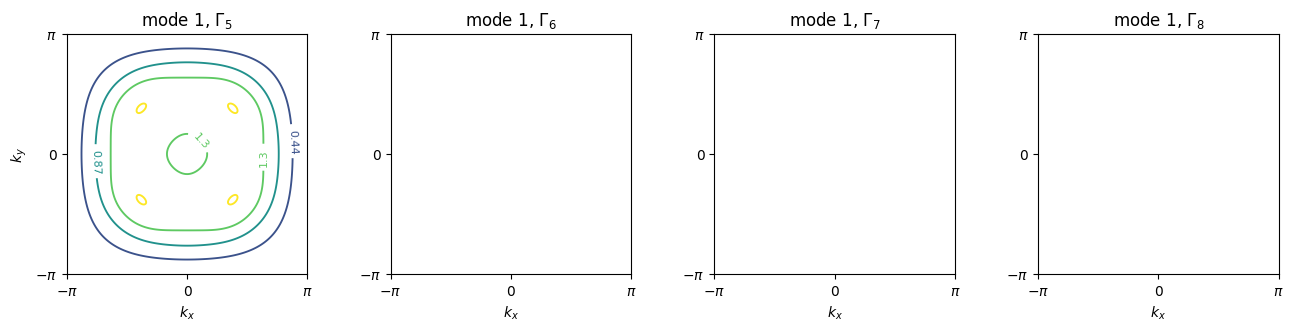

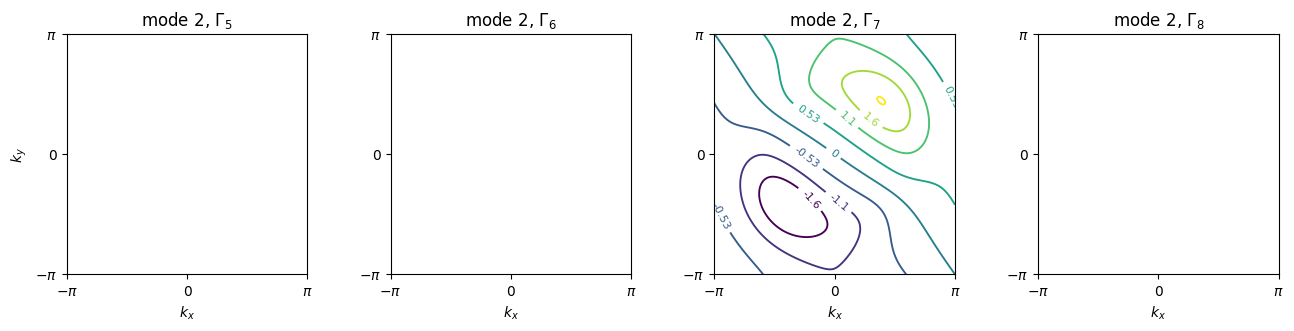

In [12]:
def run_pipeline(p: ModelParams, make_plots=False, verbose=True, plot_kwargs=None, plot_mode_numbers=(1,)):
    x, y, qx, qy, vqx, vqy, Nk, dxy, pref = make_grid(p)
    Gam = build_gamma_matrices()

    if verbose:
        print("Computing bubble and bubblep ...")
    bubble, bubblep = compute_bubbles(vqx, vqy, Gam, p, verbose=verbose)

    if verbose:
        print("Building Mchi ...")
    Mchi = build_Mchi(vqx, vqy, bubble, bubblep, p, verbose=verbose)

    if verbose:
        print("Solving eigensystem ...")
    evals, evecs = solve_eigenproblem(Mchi, pref, p.num_eigs)

    label, weights, ft = classify_leading_mode(evecs[:, 0], Nk, tol=p.classify_tol)
    Q = orthonormalize_columns(evecs[:, : min(4, evecs.shape[1])])
    basis_report = basis_projection_report(Q, qx, qy, Nk)
    summary_rows = mode_summary_rows(evals, evecs, Nk, tol=p.classify_tol)
    dominant_component_report = dominant_component_rows(evecs, qx, qy, Nk, tol=p.classify_tol)
    leading_component_projection = dominant_component_projection_rows(evecs[:, 0], qx, qy, Nk, tol=p.classify_tol)
    decision_rows = symmetry_decision_rows(evecs[:, 0], Nk, tol=p.classify_tol)
    projection_rows = harmonic_projection_rows(Q, qx, qy, Nk)

    if p.save_outputs:
        np.save("chi2_evals.npy", evals)
        np.save("chi2_evecs.npy", evecs)
        np.save("chi2_leading_mode_grid.npy", real_mode_grid(evecs[:, 0], Nk))
        np.save("chi2_channel_weights.npy", weights)

    print("\n=== Results ===")
    print(f"prefactor               : {pref:.6e}")
    print(f"approx array memory [GB]: {array_memory_gb(bubble, bubblep, Mchi):.3f}")
    print(f"leading eigenvalue      : {evals[0]}")
    print("lambda criterion        : if this kernel has the same normalization as the paper, Tc is where leading lambda(T) crosses 1")
    print(f"identified channel      : {label}")
    print()
    print_table(
        "Leading modes",
        ["mode", "Re(lambda)", "Im(lambda)", "lambda/lambda1", "1-ratio", "block", "label", "Gamma1-4", "Gamma5-6", "Gamma7-8"],
        summary_rows,
    )
    print()
    print_table("Leading-mode channel weights", ["Gamma", "basis matrix", "L1 weight", "fraction"], channel_weight_rows(weights))
    print()
    print_table(
        "Dominant component per mode",
        ["mode", "component", "basis matrix", "weight", "fraction", "best harmonic", "coeff", "overlap", "label"],
        dominant_component_report,
    )
    print()
    print_table(
        "Leading dominant-component harmonic projections",
        ["component", "basis matrix", "harmonic", "coeff", "overlap", "abs overlap"],
        leading_component_projection,
    )
    print()
    print_table("Leading-mode symmetry decision", ["check", "value", "meaning"], decision_rows)

    if p.save_outputs:
        print("\nSaved:")
        print("  chi2_evals.npy")
        print("  chi2_evecs.npy")
        print("  chi2_leading_mode_grid.npy")
        print("  chi2_channel_weights.npy")

    results = {
        "params": p,
        "grid": (x, y, qx, qy, vqx, vqy, Nk, dxy, pref),
        "bubble": bubble,
        "bubblep": bubblep,
        "Mchi": Mchi,
        "evals": evals,
        "evecs": evecs,
        "label": label,
        "weights": weights,
        "Q": Q,
        "basis_report": basis_report,
        "summary_rows": summary_rows,
        "dominant_component_report": dominant_component_report,
        "leading_component_projection": leading_component_projection,
        "decision_rows": decision_rows,
        "projection_rows": projection_rows,
    }

    if make_plots:
        if plot_kwargs is None:
            plot_kwargs = {}
        if isinstance(plot_mode_numbers, int):
            plot_mode_numbers = (plot_mode_numbers,)
        for mode_number in plot_mode_numbers:
            mode_index = int(mode_number) - 1
            if mode_index < 0 or mode_index >= evecs.shape[1]:
                print(f"Skipping mode {mode_number}: only {evecs.shape[1]} modes were computed.")
                continue
            plot_leading_mode_components(
                evecs[:, mode_index],
                x,
                y,
                Nk,
                channel_ids=(4, 5, 6, 7),
                mode_number=mode_number,
                **plot_kwargs,
            )
            plt.show()

    return results


# Default behavior: run a tiny preview so the result tables are visible
# without launching the expensive full grid calculation.
run_full_problem = True
run_preview_problem = False
make_result_plots = True
make_paper_style_plot = False
plot_mode_numbers = (1, 2)  # plot raw eigenmodes; useful when mode 1 and mode 2 are degenerate
plot_grid_points = 301  # visual interpolation grid; set None to plot the raw solver grid
plot_num_levels = 9
plot_level_scale = "shared"  # use "component" to draw plot_num_levels contours in every panel
plot_options = {
    "plot_grid_points": plot_grid_points,
    "num_levels": plot_num_levels,
    "level_scale": plot_level_scale,
}
paper_plot_options = {
    "gid": 6,  # Gamma5, the dominant s'/d' component in this run
    "target_peak": -2.0,
    "level_step": 0.2,
    "plot_grid_points": 401,
}

if run_full_problem:
    results = run_pipeline(
        params,
        make_plots=make_result_plots,
        verbose=True,
        plot_kwargs=plot_options,
        plot_mode_numbers=plot_mode_numbers,
    )
elif run_preview_problem:
    preview_params = ModelParams(**{
        **params.__dict__,
        "Nk_base": 5,
        "num_eigs": min(params.num_eigs, 6),
        "save_outputs": False,
    })
    print("Running a small preview calculation so the result tables are visible.")
    print("For production results, set run_full_problem = True and choose params.Nk_base, e.g. 31 for the MATLAB grid.")
    results = run_pipeline(
        preview_params,
        make_plots=make_result_plots,
        verbose=False,
        plot_kwargs=plot_options,
        plot_mode_numbers=plot_mode_numbers,
    )
else:
    print("No calculation was run.")
    print("Set run_preview_problem = True for a small demo output, or run_full_problem = True for the full calculation.")
    print("For a closer match to chi2_old.m, also set params.Nk_base = 31.")

if make_paper_style_plot and "results" in locals():
    x, y, qx, qy, vqx, vqy, Nk, dxy, pref = results["grid"]
    plot_paper_style_component(
        results["evecs"][:, 0],
        x,
        y,
        Nk,
        mu=results["params"].mu,
        **paper_plot_options,
    )
    plt.show()


## Reading the output

A few quick interpretations of the printed diagnostics:

- `Leading modes`: compares the first few eigenmodes. `lambda/lambda1` close to 1 means another channel is nearly degenerate with the leading one; `1-ratio` is the same kind of separation diagnostic as the MATLAB line `1-d(3)/d(1)`.
- `Leading-mode channel weights`: shows how much of the leading eigenvector lives in each of the eight `Gamma` components. These weights are computed as `w_i = sum_k |Delta_i(k)|` after reshaping the eigenvector into `Delta_i(kx, ky)`.
- `Dominant component per mode`: for each low-lying mode, finds the single largest `Gamma_i` component by this weight, then projects only that component onto the article-style harmonics `sin(kx/2) sin(ky/2)`, `cos(kx/2) cos(ky/2)`, and `sin((kx +/- ky)/2)`. This is the table to use when reading the mode as `d'`, `s'`, or `p'`-like.
- `Leading dominant-component harmonic projections`: shows the full harmonic projection list for the dominant component of the leading mode. `coeff` is the least-squares coefficient in that harmonic direction; `overlap` is the normalized inner product, so `abs overlap` closer to 1 means a cleaner match.
- The figures produced by `make_result_plots = True` show the raw eigenmodes selected by `plot_mode_numbers`, in the selected `Gamma5:Gamma8` components. All four panels share the same contour-level scale by default, so subdominant components stay visually small instead of being rescaled to look important.
- `Leading-mode symmetry decision`: spells out the block-level classification rule. With the paper ordering, the blocks are `Gamma1:Gamma4` for p-wave, `Gamma5:Gamma6` for s'/d', and `Gamma7:Gamma8` for p'. Inside the `Gamma5:Gamma6` sector, the flip sign test is only a quick diagnostic for s' versus d'; the harmonic projection table is the preferred check.

The saved arrays are mainly meant for post-processing and plotting. In particular, `chi2_leading_mode_grid.npy` stores the phase-aligned real part of the leading eigenvector reshaped to `(Nk, Nk, 8)`, which is convenient when comparing form factors channel by channel.

Why there is no required harmonic expansion step: the linearized gap equation is being diagonalized directly on the momentum grid and in the finite internal `Gamma` basis. The eigenvector itself is already the discretized gap function, with components `Delta_a(kx, ky)` for `a = 1, ..., 8`. A harmonic expansion such as projecting onto `sin(qx)`, `sin(qy)`, `cos(qx)-cos(qy)`, and so on is therefore optional interpretation/post-processing. It becomes necessary only if you want compact analytic coefficients, a controlled truncated basis calculation, or a more detailed symmetry decomposition than the MATLAB script's channel-weight/sign-test classifier.

About the common statement `lambda = 1`: in most papers the linearized gap equation is written as `lambda(T) Delta = K(T) Delta`, and the transition temperature is defined by the crossing condition `lambda_max(Tc) = 1`. A value larger than 1 at a fixed temperature usually means that this temperature is already below the instability scale, or that the kernel normalization/coupling convention is different. The small preview calculation in this notebook is only for checking the output format, so its absolute eigenvalue should not be compared directly with a paper figure.
